# Fine-tuning Embeddings and Advanced Retrieval

## Overview

- Label data using an LLM which is an assistant to generate questions about a scientific article

- Use another LLM to evaluate the quality of generated questions (targets) according to the context and a custom metric of quality that we define here

- Generate performance metrics for the labeled dataset

- Use the labeled dataset to evaluate retriever metrics

- Make final adjustments to the prep dataset to use it for fine-tuning an embedding model

## Setups

In [0]:
%sql
-- setup to catalog and schema
use catalog `studies`;
use schema `databricks_finetuning`;

In [0]:
VS_ENDPOINT_NAME='article_vs_endpoint'
VS_INDEX_NAME = 'article_vs_index'
CHUNKS_TABLE_NAME = 'article_chunks'
EVAL_DATASET_NAME = 'eval_dataset'
OUTPUT_TABLE_NAME = 'generated_questions_llm'
EVAL_SET_PREDS = 'eval_set_preds'

EXPORT_EVAL_SET_PREDS = True
PERSIST_GENERATED_QUESTIONS_TABLE = True
EXPORT_EVAL_DATASET_NAME = True
EXPORT_TRAINING_DATASET = True
EXPORT_EVALUATION_DATASET = True
RUN_GENERATE_QUESTIONS_LLM = True

N_MAX = 500

SERVING_MODELS = {
    'meta-llama-8b': 'databricks-meta-llama-3-1-8b-instruct',  # enabled
    'qwen-80b': 'databricks-qwen3-next-80b-a3b-instruct',  # enabled
    'llama-maverick-400b': 'databricks-llama-4-maverick', # enabled
    'gemma-12b': 'databricks-gemma-3-12b',  # enabled
    'gpt-5-1': 'databricks-gpt-5-1',  # disabled
    'gpt-oss-20b': 'databricks-gpt-oss-20b'  # disabled
}


infos_env = spark.sql('SELECT current_catalog(), current_schema()').collect()[0]
CATALOG = infos_env[0]
SCHEMA = infos_env[1]
print(f'Catalog: {CATALOG}')
print(f'Schema: {SCHEMA}')

Catalog: studies
Schema: databricks_finetuning


In [0]:
import warnings
warnings.filterwarnings('ignore')

import json
from typing import List
from rich import print
import pandas as pd
pd.set_option('display.max_colwidth', None)

from databricks.sdk.service.serving import ChatMessage, ChatMessageRole

from pyspark.sql.functions import col

import mlflow
from mlflow.metrics.genai import make_genai_metric, EvaluationExample

from databricks.sdk import WorkspaceClient
from databricks.vector_search.client import VectorSearchClient

In [0]:
ws_client = WorkspaceClient()
vs_client = VectorSearchClient(disable_notice=True)

In [0]:
chunks_path = f'{CATALOG}.{SCHEMA}.{CHUNKS_TABLE_NAME}'

sent_question_filter = 'misinformation'

filtered_content = (
	spark
 	.table(chunks_path)
	.filter(col('chunk').contains(sent_question_filter))
)

filtered_content = filtered_content.toPandas()
filtered_content = filtered_content.head(N_MAX)
print(filtered_content.shape)
display(filtered_content.sample(5))

(83, 3)

path,chunk,id
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,"eported receiving at least some of their news from social media (Levy (2021)). At the same time, there is growing concern about viral misinformation in social media, including made-up news stories such as those claiming that there were no mass shootings under Donald Trump or that Hillary Clinton app",126
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs7_9_model.pdf,"ponent of utility, $U_{i}^{j(2)}$ , increases, raising the overall utility of sharing. Similarly, when others reduce their likelihood of disliking, meaning that now $b_{i}^*$ (weakly) decreases for all $i$ , this reduces the likely cost of sharing misinformation by",253
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs27_30_refs.pdf,"Vicario, Michela Del, Alessandro Bessi, Fabiana Zollo, Fabio Petroni, Antonio Scala, Guido Caldarelli, H. Eugene Stanley, and Walter Quattrociocchi (2016), ""The spreading of misinformation online."" Proceedings of the National Academy of Sciences, 113, 554–559.",122
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"We consider the effects of these policies both on a fixed sharing network and when the platform can optimally choose the sharing network given public policy. For simplicity, we suppose the regulator's objective is to decrease the virality of articles containing misinformation on the platform.20 We",25
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,e reputation loss from being called out for sharing content containing misinformation. Agents additionally receive utility from disliking (or calling out) items that they believe contain misinformation.,144


## Prepare data

In [0]:
def llm_request(
    llm_endpoint: str,
    context: str
) -> str:
    
    system_prompt = '''You are a research assistant who is going to ask a specialized key question related to the provided context. Format your question placing it between single quotation marks. Here are some examples of good questions and answers with the provided content:

    *Example 1*
    Question: 'What were the principal results of the paper?'
    Answer: Homophily creates echo chambers that reduce scrutiny, enabling engagement-driven platforms to amplify misinformation through positive feedback and limited criticism.

    *Example 2*
    Question: 'How does the work propose to treat misinformation?'
    Answer: Misinformation spreads when agents share articles expecting positive social media feedback and little negative reactions.
    '''

    user_prompt = ''''Context: {context}
    Make a good question about the article.
    '''

    messages = [
		ChatMessage(
			role=ChatMessageRole('system'),
			content=system_prompt
        ),
        ChatMessage(
                role=ChatMessageRole('user'),
                content=user_prompt.format(context=context)
        )
    ]
    ws_client = WorkspaceClient()
    res = ws_client.serving_endpoints.query(
		name=llm_endpoint,
		messages=messages
	)

    return res.choices[0].message.content

In [0]:
if RUN_GENERATE_QUESTIONS_LLM:
    endpoint_qwen = SERVING_MODELS['qwen-80b']
    filtered_content['generated_questions_llm'] = filtered_content['chunk'].apply(
        lambda x: llm_request(llm_endpoint=endpoint_qwen, context=x)
    )
else:
    eval_path = f'{CATALOG}.{SCHEMA}.{EVAL_DATASET_NAME}'
    filtered_content = (
        spark
        .table(eval_path)
    ).toPandas()
    filtered_content.rename(columns={'inputs': 'chunk', 'preds': 'generated_questions_llm'}, inplace=True)
print(filtered_content.shape)
display(filtered_content.sample(5))

(83, 4)

path,chunk,id,generated_questions_llm
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,"n are greater. It is particularly telling that homophily leads to the viral spread of low-reliability content, which are the ones more likely to contain misinformation.",154,'Why does homophily contribute to the viral spread of low-reliability content?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,"backfire when it instills a sense of ""false security"" that the content has been verified by previous social media users. Second, we look at potential censorship of articles identified by a regulator as likely containing misinformation. While censorship can help reduce the viral spread of misinforma",166,"'How can fact-checking interventions backfire by creating a sense of ""false security"" among social media users?'"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"our news feed sounds just like you.” Telligly in this context, while Facebook cracked down on misinformation prior to the 2020 election in part due to political pressure, its algorithms have resumed promotion of misinformation in November and December of 2020: ""...the measures [Facebook] could take",18,'Why did Facebook resume promoting misinformation in November and December 2020 despite prior crackdowns ahead of the 2020 election?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,19 See Vanity Fair: https://www.vanityfair.com/news/2020/12/with-the-election-over-facebook-gets-back-to-spreading-misinformation and also https://www.technologyreview.com/2021/03/11/1020600/facebook-responsible-ai-misinformation/. 17,22,"'How did Facebook resume spreading misinformation after the 2020 election, according to the Vanity Fair and MIT Technology Review articles?'"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,now briefly discuss four distinct types of regulations that have been discussed in this context: (1) regulations that force platforms to reveal articles' provenance; (2) censorship or tagging of misinformation; (3) performance targets that require the platform to keep misinformation below a given t,23,'What are the four distinct types of regulations discussed for addressing misinformation on platforms?'


In [0]:
filtered_content.path.value_counts(dropna=False)

path
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf           30
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf     14
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs7_9_model.pdf           14
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf    13
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs27_30_refs.pdf           8
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pg2_abstract.pdf            4
Name: count, dtype: int64

## Evaluate the questions quality

### Examples to custom metric 

In [0]:
ex_sent_filter1 = 'misinformation'
ex_context1 = filtered_content[filtered_content.chunk.str.contains(ex_sent_filter1)].chunk.values[0]
ex_question1 = filtered_content[filtered_content.chunk.str.contains(ex_sent_filter1)].generated_questions_llm.values[0]

print('Example 1')
print(f'Context 1: {ex_context1}')
print(f'\nQuestion 1: {ex_question1}')

example_genai = EvaluationExample(
	input=ex_context1,
	output=[ex_question1],
	score=5,
	justification=(
		'Moderately aligned with the context but still somewhat generic.'
	)
)

Example 1

Context 1: We present a model of online content sharing where agents sequentially observe an article and must 
decide whether to share it with others. This content may or may not contain misinformation. Agents gain utility 
from positive social media interactions but do not want to be called out for propagating

Question 1: 'How do agents' motivations for positive social media interactions influence the spread of 
misinformation in the proposed model?'

In [0]:
ex_sent_filter2 = 'homophily'
ex_context2 = filtered_content[filtered_content.generated_questions_llm.str.contains(ex_sent_filter2)].chunk.values[0]
ex_question2 = filtered_content[filtered_content.generated_questions_llm.str.contains(ex_sent_filter2)].generated_questions_llm.values[0]

print('Example 2')
print(f'Context: {ex_context2}')
print(f'\nQuestion: {ex_question2}')

example_genai2 = EvaluationExample(
	input=ex_context2,
	output=[ex_question2],
	score=8,
	justification=(
	'Strongly grounded in the context with appropriate terminology usage.'
	)
)

Example 2

Context: be called out for propagating misinformation. We characterize the (Bayesian-Nash) equilibria of this 
social media game and show sharing exhibits strategic complementarity. Our first main result establishes that the 
impact of homophily on content virality is non-monotone: homophily reduces the broad

Question: 'How does homophily non-monotonically affect content virality in the Bayesian-Nash equilibrium of the 
social media sharing game?'

In [0]:
filtered_content[filtered_content.generated_questions_llm.str.contains(ex_sent_filter2)]

,path,chunk,id,generated_questions_llm
1,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pg2_abstract.pdf,be called out for propagating misinformation. We characterize the (Bayesian-Nash) equilibria of this social media game and show sharing exhibits strategic complementarity. Our first main result establishes that the impact of homophily on content virality is non-monotone: homophily reduces the broad,2,'How does homophily non-monotonically affect content virality in the Bayesian-Nash equilibrium of the social media sharing game?'
6,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,6 Regulation\nOur analysis so far raises the natural question of what types of regulations might counter the viral spread of misinformation and platform choices leading to excessive ideological homophily. We\n19 See Vanity Fair:,21,'What types of regulations does the paper suggest could counter the viral spread of misinformation and excessive ideological homophily on platforms?'
9,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"misinformation below a given threshold; (4) network regulations, restricting the extent of ideological homophily or segregation introduced by platform algorithms intended to maximize engagement.",24,'How do network regulations aim to mitigate the spread of misinformation by addressing ideological homophily in platform algorithms?'
23,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"ity of content. Because this article is unlikely to contain misinformation, it is of broad appeal to a wide range of social media users, independent of ideology. An increase in homophily then reduces the extent to which this article can spread throughout the sharing network. The implications of homo",50,'How does increased homophily affect the spread of content that is unlikely to contain misinformation and has broad ideological appeal?'
24,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"can suffer from spreading misinformation, even those who agree with their message would not share them widely. In contrast, high homophily creates echo chambers, where users share low-reliability messages aligned with their beliefs, because they understand that there are few negative reputational c",52,'How does high homophily contribute to the spread of low-reliability misinformation within online communities?'
27,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"r setting, it brought out certain new strategic forces—highlighting how social media actions exhibit strategic complementarity and how the degree of homophily alters agents' strategic behavior. Nevertheless, misinformation may be particularly damaging when agents have cognitive limitations and are o",63,'How do cognitive limitations and homophily interact to influence the strategic behavior of agents in the spread of misinformation on social media?'
38,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs27_30_refs.pdf,"Vicario, Michela Del, Alessandro Bessi, Fabiana Zollo, Fabio Petroni, Antonio Scala, Guido Caldarelli,\nH. Eugene Stanley, and Walter Quattrociocchi (2016), ""The spreading of misinformation online.""\nProceedings of the National Academy of Sciences, 113, 554–559.",122,'How does homophily contribute to the spread of misinformation on online platforms according to Vicario et al. (2016)?'
49,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,"gically similar to them). Low levels of homophily ensure that agents are likely to be exposed to cross-cutting content, including ""counter-attitudinal articles"" that advocate views opposed to theirs. This in turn ensures that misinformation is unlikely to survive for very long. Perhaps paradoxically",150,'How does low homophily contribute to the downfall of misinformation?'
51,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro

In [0]:
ex_context3 = filtered_content[filtered_content.generated_questions_llm.str.contains(ex_sent_filter2)].iloc[9].chunk
ex_question3 = filtered_content[filtered_content.generated_questions_llm.str.contains(ex_sent_filter2)].iloc[9].generated_questions_llm

print('Example 3')
print(f'Context: {ex_context3}')
print(f'\nQuestion: {ex_question3}')

example_genai3 = EvaluationExample(
	input=ex_context3,
	output=[ex_question3],
	score=2,
	justification=(
		'Barely related to the article topic.'
	)
)

Example 3

Context: a striking result: when the relevant articles have low reliability, social media platforms that aim to 
maximize engagement will tend to design algorithms that increase homophily and create filter bubbles, propagating 
misinformation. Intuitively, high-reliability content tends to spread anyway becau

Question: 'Why do social media platforms that maximize engagement tend to increase homophily when promoting 
low-reliability content?'

In [0]:
gradind_prompt = ('''
You are evaluating the quality of a question generated from a given article context.

Your goal is to measure how well the question aligns with the provided context,
without being overly specific or overly generic.

Scoring scale (0–10):

0 = Not a question at all.
1 = Completely unrelated to the article.
2 = Barely related to the article topic.
3 = Vaguely related but very generic.
4 = Related but does not reference concrete information from the context.
5 = Moderately aligned with the context but still somewhat generic.
6 = Clearly grounded in the context with correct terminology.
7 = Well-aligned and meaningfully connected to a specific part of the context.
8 = Strongly grounded in the context with appropriate terminology usage.
9 = Very precise and tightly connected to the context without excessive wording.
10 = Perfectly aligned, precise, context-aware, and well-formed.

Guidelines:
- Penalize hallucinated terms not present in the context.
- Penalize excessive specificity that makes the question unnatural.
- Reward clarity, contextual grounding, and appropriate scope.

Return ONLY a single integer between 0 and 10.
Do not explain your answer.
Do not return anything else.
''')

In [0]:
custom_metric = make_genai_metric(
	name='QuestionQualityMetric',
	definition=('Evaluate the qualitity of the LLM generated questions.'),
	grading_prompt=gradind_prompt,
	model=f'endpoints:/{SERVING_MODELS['meta-llama-8b']}',
	examples=[example_genai, example_genai2, example_genai3],
	parameters={'temperature': 0.1},
	greater_is_better=True,
)

In [0]:
eval_dataset = filtered_content.copy()
eval_dataset.rename(columns={'generated_questions_llm': 'preds', 'chunk': 'inputs'}, inplace=True)
print(eval_dataset.shape)
eval_dataset.sample(5)

(83, 4)

,path,inputs,id,preds
15,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"20Formally, the regulator minimizes the virality of content conditional on the article containing misinformation, in mathematical notation, the regulator minimizes $\mathbb{E}_{max}^*|\mathbf{S}_v|\, \nu = M|$.",37,"'What is the formal objective of the regulator in controlling misinformation virality, as expressed mathematically?'"
77,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs7_9_model.pdf,"probability 1, and is always preferred to ignoring for an article that contains misinformation with probability 1.",227,'Why is sharing an article with probability 1 of containing misinformation always preferred over ignoring it?'
2,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pg2_abstract.pdf,"ximizing engagement tend to design their algorithms to create more homophilic communication patterns (""filter bubbles""). We show that platform incentives to amplify misinformation are particularly pronounced for low-reliability content likely to contain misinformation and when there is greater polar",4,"'Why do platforms incentivize the amplification of low-reliability content, and how does polarization influence this dynamic?'"
55,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs3_6_intro.pdf,"If platform algorithms are propagating misinformation, can public policy counter and discourage this type of behavior?4 The answer is yes, but with some caveats. In the last part of the paper, we discuss four different types of regulatory policies, and in each case, we show how they may reduce misi",163,'What are the four types of regulatory policies discussed in the paper that could counter misinformation propagated by platform algorithms?'
18,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"latform. Articles may be truthful and informative about an underlying state, or may contain misinformation, making them (weakly) anti-correlated with the underlying state. Upon receiving an article, an agent can decide to share it with others, ignore it, or actively call out another agent for propag",42,"'How do agents decide whether to share, ignore, or call out an article, and how does the truthfulness of the article influence their behavior?'"


In [0]:
print(EVAL_DATASET_NAME)

eval_dataset

In [0]:
if EXPORT_EVAL_DATASET_NAME:
    spark.createDataFrame(eval_dataset).write.format('delta').mode('overwrite').saveAsTable(EVAL_DATASET_NAME)
else:
    pass


<img src='./imgs/table_eval_dataset.png'>

### Evaluate question quality using a custom metric

In [0]:
with mlflow.start_run() as run:
	results_eval = mlflow.evaluate(
		data=eval_dataset,
		predictions='preds',
		model_type='question-answering',
		extra_metrics=[custom_metric]
	)

2026/02/26 10:30:10 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...


config.json:   0%|          | 0.00/816 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: facebook/roberta-hate-speech-dynabench-r4-target
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

2026/02/26 10:30:22 WARNING mlflow.models.evaluation.utils.metric: Did not log metric 'exact_match' at index 4 in the `extra_metrics` parameter because it returned None.


  0%|          | 0/1 [00:00<?, ?it/s]

2026/02/26 10:30:46 WARNING mlflow.models.evaluation.utils.metric: Did not log metric 'exact_match' at index 4 in the `extra_metrics` parameter because it returned None.


  0%|          | 0/83 [00:00<?, ?it/s]

In [0]:
df_metrics = pd.DataFrame(results_eval.metrics, index=[0]).T
df_metrics.rename(columns={0: 'grading_score'}, inplace=True)
df_metrics

,grading_score
toxicity/v1/mean,0.000687
toxicity/v1/variance,0.000001
toxicity/v1/p90,0.001361
toxicity/v1/ratio,0.000000
flesch_kincaid_grade_level/v1/mean,14.866730
flesch_kincaid_grade_level/v1/variance,7.162980
flesch_kincaid_grade_level/v1/p90,18.286040
ari_grade_level/v1/mean,16.254996
ari_grade_level/v1/variance,8.690657
ari_grade_level/v1/p90,19.659908


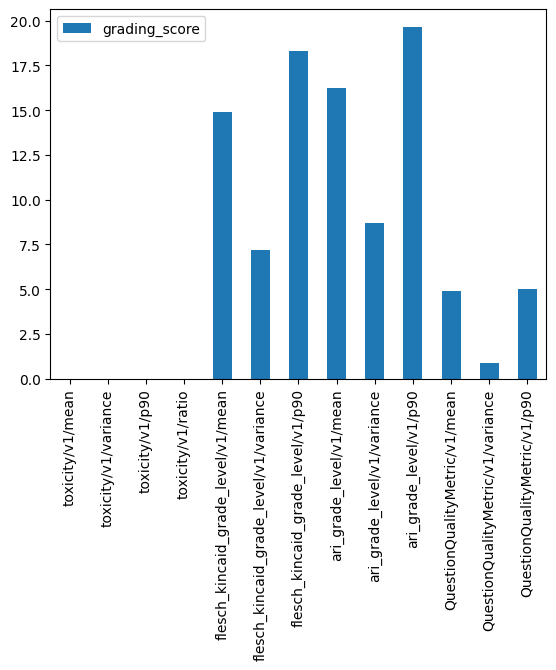

In [0]:
df_metrics.plot(kind='bar');

In [0]:
eval_results_table = pd.DataFrame.from_dict(results_eval.tables['eval_results_table'])
eval_results_table.sample(3)

,path,inputs,id,outputs,token_count,toxicity/v1/score,flesch_kincaid_grade_level/v1/score,ari_grade_level/v1/score,QuestionQualityMetric/v1/score,QuestionQualityMetric/v1/justification
10,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"We consider the effects of these policies both on a fixed sharing network and when the platform can optimally choose the sharing network given public policy. For simplicity, we suppose the regulator's objective is to decrease the virality of articles containing misinformation on the platform.20 We",25,'How does the paper model the regulator’s strategy for reducing misinformation virality when the platform can optimally choose the sharing network?',26,0.000322,16.761905,17.778571,5,Moderately aligned with the context but still somewhat generic.
77,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs7_9_model.pdf,"probability 1, and is always preferred to ignoring for an article that contains misinformation with probability 1.",227,'Why is sharing an article with probability 1 of containing misinformation always preferred over ignoring it?',19,0.002125,15.725000,14.535625,5,Moderately aligned with the context but still somewhat generic.
36,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs27_30_refs.pdf,"Pennycook, Gordon and David G. Rand (2019a), “Fighting misinformation on social media using crowdsourced judgments of news source quality,” Proceedings of the National Academy of Sciences, 116, 2521–2526.",116,'How does the study propose to combat misinformation on social media using crowdsourced judgments of news source quality?',21,0.000403,13.063333,15.045000,4,Related but does not reference concrete information from the context.


<Axes: ylabel='QuestionQualityMetric/v1/score'>

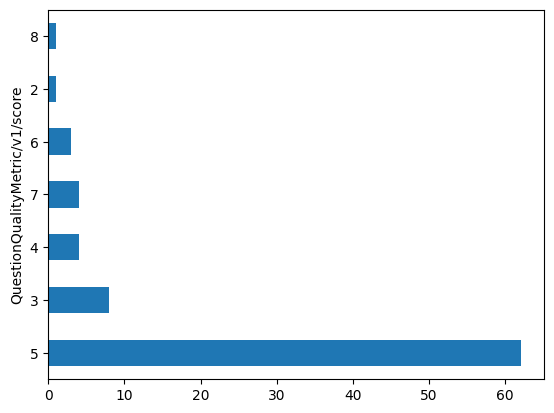

In [0]:
eval_results_table.value_counts('QuestionQualityMetric/v1/score').plot(kind='barh')

In [0]:
if PERSIST_GENERATED_QUESTIONS_TABLE:
    spark.createDataFrame(eval_results_table).write.format('delta').mode('overwrite').saveAsTable(OUTPUT_TABLE_NAME)

## Compute baseline metrics for the evaluation dataset

In [0]:
selected_content = spark.read.table(f'{CATALOG}.{SCHEMA}.{EVAL_DATASET_NAME}')
display(selected_content.show(5))

+--------------------+--------------------+---+--------------------+
|                path|              inputs| id|               preds|
+--------------------+--------------------+---+--------------------+
|dbfs:/Volumes/stu...|We present a mode...|  1|'How do agents' m...|
|dbfs:/Volumes/stu...|be called out for...|  2|'How does homophi...|
|dbfs:/Volumes/stu...|ximizing engageme...|  4|'Why do platforms...|
|dbfs:/Volumes/stu...|nd when there is ...|  5|'What regulatory ...|
|dbfs:/Volumes/stu...|In Theorem 3, the...| 11|'What does the th...|
+--------------------+--------------------+---+--------------------+
only showing top 5 rows


In [0]:
train_set, eval_set = selected_content.randomSplit(weights=[0.7, 0.3], seed=42)
eval_set_df = eval_set.toPandas()
print(eval_set_df.shape)
display(eval_set_df.head())

(25, 4)

path,inputs,id,preds
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,6 Regulation Our analysis so far raises the natural question of what types of regulations might counter the viral spread of misinformation and platform choices leading to excessive ideological homophily. We 19 See Vanity Fair:,21,'What types of regulations does the paper suggest could counter the viral spread of misinformation and excessive ideological homophily on platforms?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"We consider the effects of these policies both on a fixed sharing network and when the platform can optimally choose the sharing network given public policy. For simplicity, we suppose the regulator's objective is to decrease the virality of articles containing misinformation on the platform.20 We",25,'How does the paper model the regulator’s strategy for reducing misinformation virality when the platform can optimally choose the sharing network?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"misinformation below a given threshold; (4) network regulations, restricting the extent of ideological homophily or segregation introduced by platform algorithms intended to maximize engagement.",24,'How do network regulations aim to mitigate the spread of misinformation by addressing ideological homophily in platform algorithms?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"and recommends articles to users with aligned beliefs. These articles than spread rapidly in the ""filter bubble"" the platform's algorithms have created—because now ideologically like-minded individuals know that they are unlikely to be caught sharing misinformation in their extreme echo chambers.",58,'How do algorithmic recommendations contribute to the spread of misinformation within filter bubbles?'
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"f misinformation, agents will be uncertain about how to interpret articles that disagree with their priors and this may place an upper bound on the speed and possibility of learning (see Acemoglu et al. (2016)).",69,'How does misinformation affect agents' ability to learn when they encounter articles that contradict their priors?'


In [0]:
def query_vs_docs(
  query_text: str,
  index_name: str, 
  num_results: int,
  vs_client: VectorSearchClient
) -> List[dict]:
	'''Search on vector index and returns results.'''
	
	cols = ['path', 'chunk', 'id']
	res = vs_client.get_index(index_name=index_name).similarity_search(
		query_text=query_text,
		num_results=num_results,
		columns=cols
	)
	res_pd = pd.DataFrame(res['result']['data_array'])
	res_pd.columns = [col['name'] for col in res['manifest']['columns']]
	return json.loads(res_pd.to_json(orient='records'))


def get_id_docs_from_query(question: str, vs_client: VectorSearchClient, verbose: bool = False) -> List[float]:
    ans = query_vs_docs(
		query_text=question,
		index_name= f'{CATALOG}.{SCHEMA}.{VS_INDEX_NAME}',
		num_results=2,
		vs_client=vs_client
	)
    if verbose: 
        print(ans)

    return [i.get('id', None) for i in ans]

In [0]:
eval_set_df['retrieved_docs'] = eval_set_df['preds'].transform(
    lambda x: get_id_docs_from_query(x, vs_client)
)
display(eval_set_df)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. T

path,inputs,id,preds,retrieved_docs
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,6 Regulation Our analysis so far raises the natural question of what types of regulations might counter the viral spread of misinformation and platform choices leading to excessive ideological homophily. We 19 See Vanity Fair:,21,'What types of regulations does the paper suggest could counter the viral spread of misinformation and excessive ideological homophily on platforms?',"List(21.0, 169.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"We consider the effects of these policies both on a fixed sharing network and when the platform can optimally choose the sharing network given public policy. For simplicity, we suppose the regulator's objective is to decrease the virality of articles containing misinformation on the platform.20 We",25,'How does the paper model the regulator’s strategy for reducing misinformation virality when the platform can optimally choose the sharing network?',"List(25.0, 26.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,"misinformation below a given threshold; (4) network regulations, restricting the extent of ideological homophily or segregation introduced by platform algorithms intended to maximize engagement.",24,'How do network regulations aim to mitigate the spread of misinformation by addressing ideological homophily in platform algorithms?',"List(21.0, 24.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"and recommends articles to users with aligned beliefs. These articles than spread rapidly in the ""filter bubble"" the platform's algorithms have created—because now ideologically like-minded individuals know that they are unlikely to be caught sharing misinformation in their extreme echo chambers.",58,'How do algorithmic recommendations contribute to the spread of misinformation within filter bubbles?',"List(158.0, 4.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"f misinformation, agents will be uncertain about how to interpret articles that disagree with their priors and this may place an upper bound on the speed and possibility of learning (see Acemoglu et al. (2016)).",69,'How does misinformation affect agents' ability to learn when they encounter articles that contradict their priors?',"List(69.0, 172.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"information. We can also use this extended setup with repeated interactions to study how agents update their initial political views. When there is limited misinformation, agents will gradually learn the true state. In contrast, when there is a significant probability of misinformation, agents will",68,'How does the probability of misinformation affect agents' updating of initial political views in repeated interactions?',"List(68.0, 172.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"ity of content. Because this article is unlikely to contain misinformation, it is of broad appeal to a wide range of social media users, independent of ideology. An increase in homophily then reduces the extent to which this article can spread throughout the sharing network. The implications of homo",50,'How does increased homophily affect the spread of content that is unlikely to contain misinformation and has broad ideological appeal?',"List(150.0, 154.0)"
dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs25_6_conclusion.pdf,"latform. Articles may be truthful and informative about an underlying state, or may contain misinformation, making them (weakly) anti-correlated with the underlying state. Upon receiving an article, an agent can decide to share it with others, ignore it, or actively call out another agent for propag",42,"'How do agents decide whether to share, ignore, or call out an article, and how does the 

In [0]:
eval_set_df['retrieved_docs'] = eval_set_df['retrieved_docs'].apply(lambda x: [int(i) for i in x])
eval_set_df['uuid'] = eval_set_df['id'].apply(lambda x: [int(x)])
eval_set_df.head(1)

,path,inputs,id,preds,retrieved_docs,uuid
0,dbfs:/Volumes/studies/databricks_finetuning/article_infos/pgs19_20_regulation.pdf,6 Regulation\nOur analysis so far raises the natural question of what types of regulations might counter the viral spread of misinformation and platform choices leading to excessive ideological homophily. We\n19 See Vanity Fair:,21,'What types of regulations does the paper suggest could counter the viral spread of misinformation and excessive ideological homophily on platforms?',"[21, 169]",[21]


In [0]:
assert type(eval_set_df.loc[0, 'retrieved_docs'][0]) == type(eval_set_df.loc[0, 'uuid'][0]), 'Check the type of the retrieved docs columns.'

In [0]:
if EXPORT_EVAL_SET_PREDS:
    spark.createDataFrame(eval_set_df).write.format('delta').mode('overwrite').saveAsTable(EVAL_SET_PREDS)
else:
    pass

In [0]:
with mlflow.start_run() as run:
	res_eval = mlflow.evaluate(
		data=eval_set_df,
  		targets='uuid',
		predictions='retrieved_docs',
		model_type='retriever',
		extra_metrics = (
			[mlflow.metrics.precision_at_k(i) 
			for i in range(1, 1 + min(N_MAX, eval_set_df.shape[0]))]
			+
			[mlflow.metrics.recall_at_k(i) 
			for i in range(1, 1 + min(N_MAX, eval_set_df.shape[0]))]
		)  	
	)

df_eval_metrics = pd.DataFrame(res_eval.metrics, index=[0]).T.sort_index()
df_eval_metrics

2026/02/26 10:40:21 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...


,0
ndcg_at_3/mean,0.776660
ndcg_at_3/p90,1.000000
ndcg_at_3/variance,0.108259
precision_at_1/mean,0.600000
precision_at_1/p90,1.000000
...,...
recall_at_8/p90,1.000000
recall_at_8/variance,0.105600
recall_at_9/mean,0.880000
recall_at_9/p90,1.000000


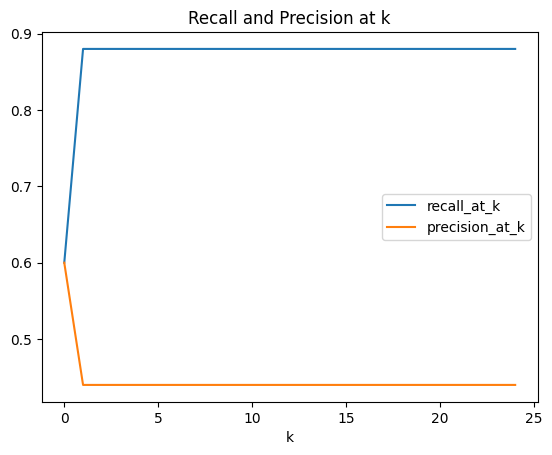

In [0]:
if res_eval.metrics:
    import matplotlib.pyplot as plt
    plt.plot([res_eval.metrics[f'recall_at_{i}/mean'] for i in range(1, 1+min(N_MAX, eval_set_df.shape[0]))], label='recall_at_k')
    plt.plot([res_eval.metrics[f'precision_at_{i}/mean'] for i in range(1, 1+min(N_MAX, eval_set_df.shape[0]))], label='precision_at_k')
    plt.title('Recall and Precision at k')
    plt.legend()
    plt.xlabel('k')
    plt.show()

<img src='./imgs/table_generated_questions_llm.png'>

## Export train and eval dataset

In [0]:
if EXPORT_TRAINING_DATASET:
    train_set.write.format('delta').mode('overwrite').saveAsTable(f'{OUTPUT_TABLE_NAME}_train')
else:
    pass

In [0]:
if EXPORT_EVALUATION_DATASET:
    eval_set.write.format('delta').mode('overwrite').saveAsTable(f'{OUTPUT_TABLE_NAME}_eval')
else:
    pass